First 5 rows:
   Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Model Evaluation:
Mean Squared Error: 3.48
Root Mean Squared Error: 1.87
R-squared: 0.85


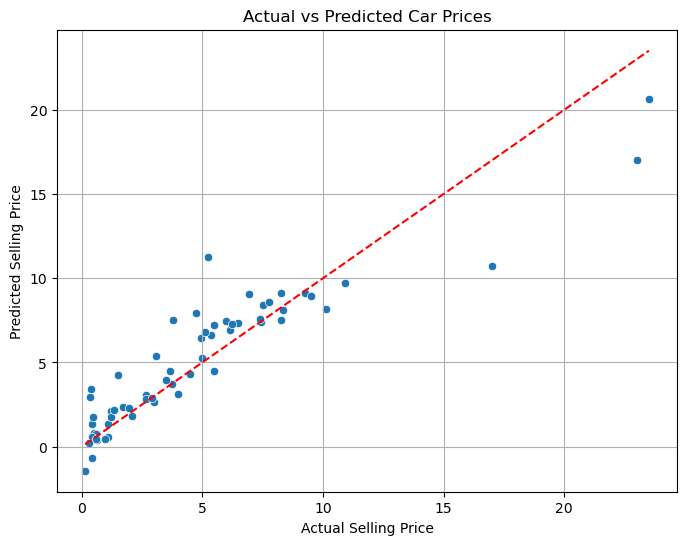


Enter your car details to predict selling price:


Fuel Type (Petrol/Diesel/CNG):  diesel
Selling Type (e.g., Individual/Dealer):  dealer
Transmission (Manual/Automatic):  automatic
Year of Manufacture:  2013
Current Price (in lakhs):  5000000
Driven Kms:  43000
Number of Previous Owners (0,1,2,...):  1



Predicted Selling Price: 2145350.14 lakhs


C:\Users\Usman\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [1]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("car data.csv")  # Make sure your CSV is in same folder
print("First 5 rows:\n", df.head())

# ==============================
# 3. Data Cleaning
# ==============================
# Drop missing values
df = df.dropna()

# Optional: Drop Car_Name if too many unique values
df = df.drop(columns=['Car_Name'])

# ==============================
# 4. Features & Target
# ==============================
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Identify numeric and categorical features
numeric_features = ['Year', 'Present_Price', 'Driven_kms', 'Owner']
categorical_features = ['Fuel_Type', 'Selling_type', 'Transmission']

# ==============================
# 5. Preprocessing Pipeline
# ==============================
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# ==============================
# 6. Train/Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==============================
# 7. Regression Model Pipeline
# ==============================
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor', LinearRegression())])

# Train model
model.fit(X_train, y_train)

# ==============================
# 8. Prediction & Evaluation
# ==============================
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

# ==============================
# 9. Visualization: Actual vs Predicted
# ==============================
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.grid(True)
plt.show()

# ==============================
# 10. User Input Prediction
# ==============================
print("\nEnter your car details to predict selling price:")

fuel = input("Fuel Type (Petrol/Diesel/CNG): ")
selling_type = input("Selling Type (e.g., Individual/Dealer): ")
transmission = input("Transmission (Manual/Automatic): ")
year = int(input("Year of Manufacture: "))
present_price = float(input("Current Price (in lakhs): "))
driven_kms = int(input("Driven Kms: "))
owner = int(input("Number of Previous Owners (0,1,2,...): "))

example_car = pd.DataFrame({
    'Year': [year],
    'Present_Price': [present_price],
    'Driven_kms': [driven_kms],
    'Owner': [owner],
    'Fuel_Type': [fuel],
    'Selling_type': [selling_type],
    'Transmission': [transmission]
})

predicted_price = model.predict(example_car)
print(f"\nPredicted Selling Price: {predicted_price[0]:.2f} lakhs")